In [10]:
import pandas as pd
import numpy as np
import polars as pl
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [37]:
import matplotlib.pyplot as plt
from pathlib import Path

# Dendogram and VIF- Full cost basis

In [38]:
ROOT = Path.cwd().parent
DATA_DIR = ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
TRAIN_PATH = RAW_DIR / "train.parquet"

In [39]:
train = pl.read_parquet(TRAIN_PATH)

In [40]:
full_cost_basis = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").str.starts_with("cost_basis_"))
    .collect()
)
len(full_cost_basis)
full_cost_basis_df = full_cost_basis.to_pandas()

In [7]:
full_cost_basis_df = full_cost_basis_df.pivot(columns='metric',index='day_utc', values='value')

In [9]:
X = (
    full_cost_basis_df
    .select_dtypes(include='number')
    .replace([np.inf, -np.inf], np.nan)
)
X = X.fillna(X.median())
X = X.loc[:, X.nunique() > 1]

X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X),
    index=X.index,
    columns=X.columns
)

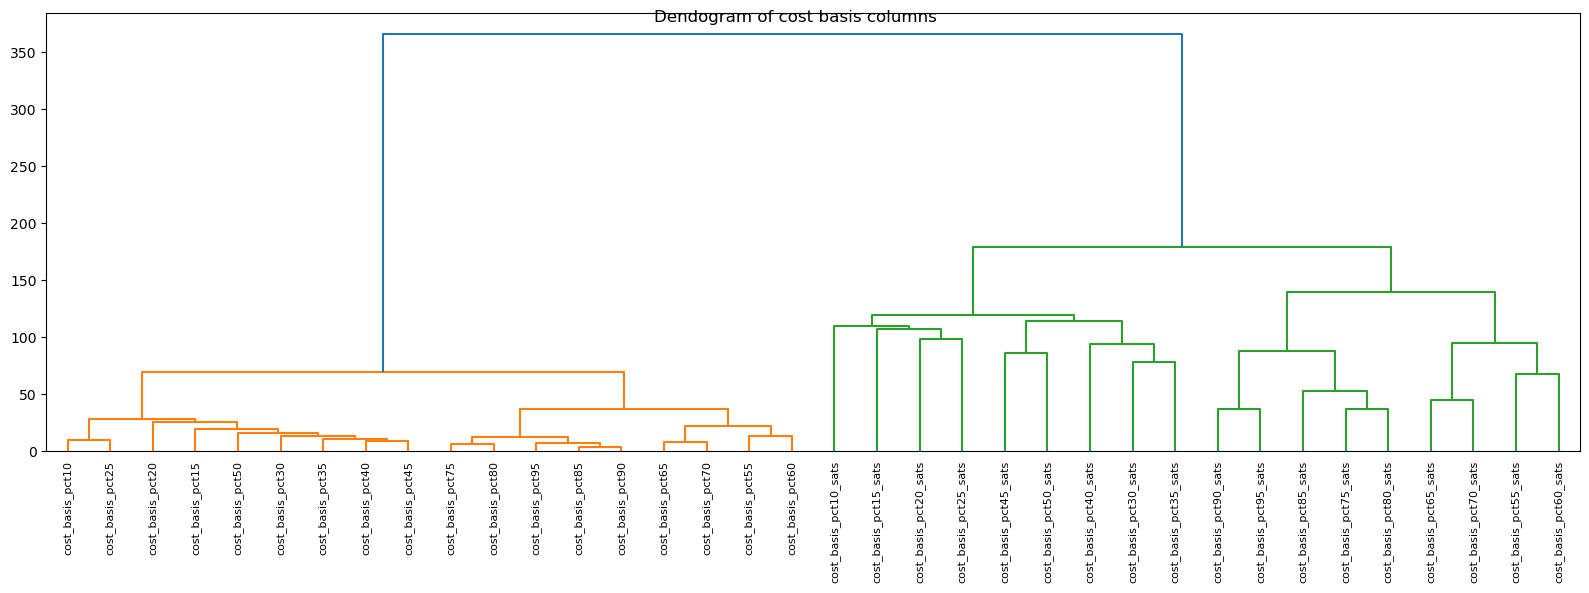

In [12]:
Z = linkage(X_scaled.T, method="ward", metric="euclidean")

fig = plt.figure(figsize=(16, 6))
dendrogram(
    Z,
    labels=X_scaled.columns,
    leaf_rotation=90,
    leaf_font_size=8
)

plt.tight_layout()
fig.suptitle("Dendogram of cost basis columns")
plt.show()

In [13]:
clusters_cost = fcluster(Z, t=5, criterion="maxclust")

cluster_map_cost = dict(zip(X_scaled.columns, clusters_cost))

cluster_df_cost = pd.DataFrame({
    "feature": X_scaled.columns,
    "cluster": clusters_cost
})
cluster_df_cost.head()

,feature,cluster
0,cost_basis_pct10,1
1,cost_basis_pct10_sats,2
2,cost_basis_pct15,1
3,cost_basis_pct15_sats,2
4,cost_basis_pct20,1


In [14]:
n = cluster_df_cost["cluster"].nunique()
clusters = {}
for i in range(1, n+1):
    clusters[i] = cluster_df_cost[cluster_df_cost["cluster"] == i]["feature"].tolist()

In [ ]:
high_vif = {}  # store results outside loop

for i in range(1, n+1):
    print(f"\nCluster {i}:")
    
    # 1. Filter to cluster's metrics and pivot to wide format
    x = (
        train.filter(pl.col("metric").is_in(clusters[i]))
        .pivot(index="day_utc", on="metric", values="value")
        .drop("day_utc")
        .to_pandas()
        .dropna()  # VIF can't handle nulls
    )
    
    if x.shape[1] < 2:
        print("  Skipping — need at least 2 features for VIF")
        continue

    # 2. Add constant and compute VIF
    X = add_constant(x)
    vif = pd.Series(
        [variance_inflation_factor(X.values, j) for j in range(X.shape[1])],
        index=X.columns
    )
    
    # 3. Drop the constant row and flag high VIF
    vif = vif.drop("const", errors="ignore")
    high_vif[i] = vif[vif > 10].index.tolist()
    
    print(vif.sort_values(ascending=False).to_string())
    print(f"\n  High VIF cols (>10): {high_vif[i]}")

In [ ]:
all_high_vif_cost_basis = [col for cols in high_vif.values() for col in cols]

In [ ]:
cluster_df_cost["cluster"].value_counts().sort_index()

# Dendogram and VIF - Address Columns

In [41]:
full_address = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").str.starts_with("addrs"))
    .collect()
)
len(full_address)
full_address_pd = full_address.to_pandas()

In [17]:
full_address_df = full_address_pd.pivot(columns='metric',index='day_utc', values='value')

In [18]:
X = (
    full_address_df
    .select_dtypes(include='number')
    .replace([np.inf, -np.inf], np.nan)
)
X = X.fillna(X.median())
X = X.loc[:, X.nunique() > 1]

X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X),
    index=X.index,
    columns=X.columns
)

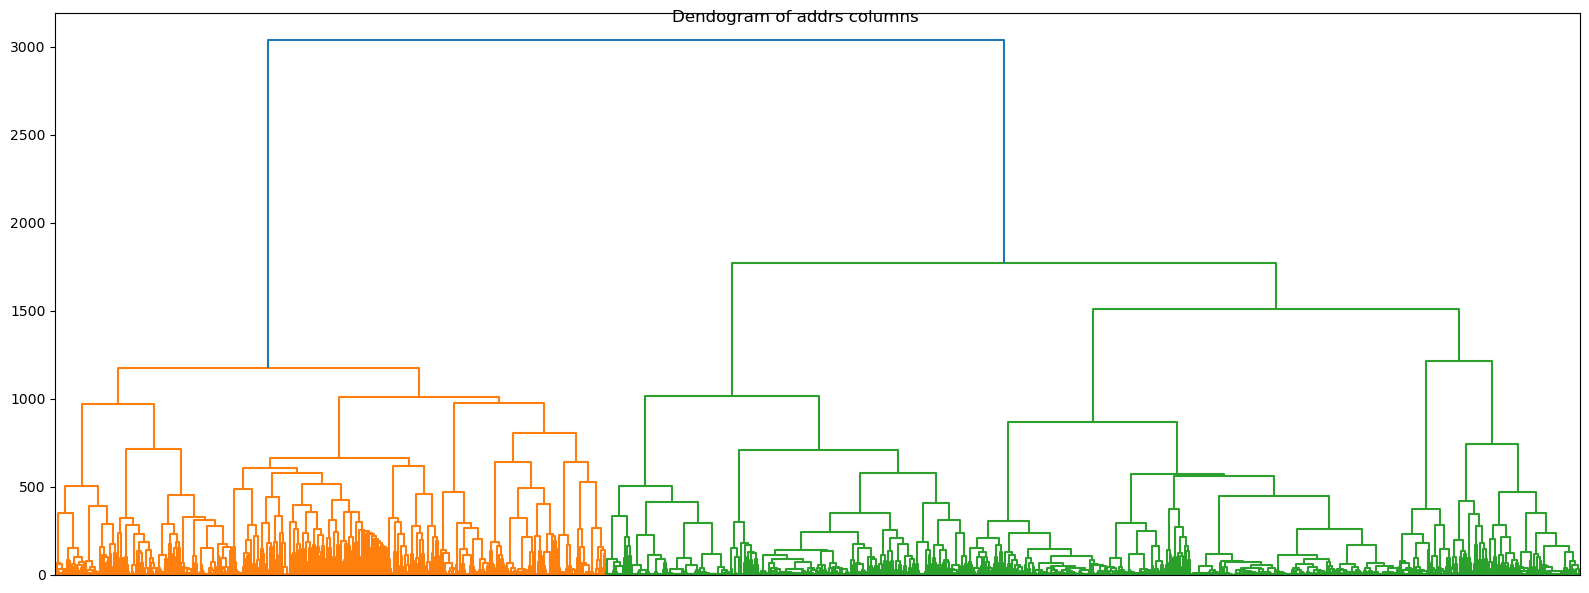

In [19]:
Z = linkage(X_scaled.T, method="ward", metric="euclidean")

fig = plt.figure(figsize=(16, 6))
dendrogram(
    Z,
    no_labels=True
)

plt.tight_layout()
fig.suptitle("Dendogram of addrs columns")
plt.show()

In [20]:
clusters_addrs = fcluster(Z, t=5, criterion="maxclust")

cluster_map_addrs = dict(zip(X_scaled.columns, clusters_addrs))


cluster_df_addrs = pd.DataFrame({
    "feature": X_scaled.columns,
    "cluster": clusters_addrs
})
cluster_df_addrs.head()

,feature,cluster
0,addrs_above_100btc_under_1k_btc__30d_change,1
1,addrs_above_100btc_under_1k_btc__30d_change_btc,1
2,addrs_above_100btc_under_1k_btc__30d_change_usd,1
3,addrs_above_100btc_under_1k_btc_addr_count,5
4,addrs_above_100btc_under_1k_btc_addr_count_30d...,1


In [21]:
cluster_df_addrs["cluster"].value_counts().sort_index()

cluster
1    1830
2    1207
3    1429
4     174
5     429
Name: count, dtype: int64

In [ ]:
n = cluster_df_addrs["cluster"].nunique()
clusters_addrs_dict = {}
for i in range(1, n+1):
    clusters_addrs_dict[i] = cluster_df_addrs[cluster_df_addrs["cluster"] == i]["feature"].tolist()


high_vif_addrs = {}  # store results outside loop

for i in range(1, n+1):
    print(f"\nCluster {i}:")
    
    # 1. Filter to cluster's metrics and pivot to wide format
    x = (
        train.filter(pl.col("metric").is_in(clusters_addrs_dict[i]))
        .pivot(index="day_utc", on="metric", values="value")
        .drop("day_utc")
        .to_pandas()
        .dropna()  # VIF can't handle nulls
    )
    
    if x.shape[1] < 2:
        print("  Skipping — need at least 2 features for VIF")
        continue

    # 2. Add constant and compute VIF
    X = add_constant(x)
    vif = pd.Series(
        [variance_inflation_factor(X.values, j) for j in range(X.shape[1])],
        index=X.columns
    )
    
    # 3. Drop the constant row and flag high VIF
    vif = vif.drop("const", errors="ignore")
    high_vif_addrs[i] = vif[vif > 10].index.tolist()
    
    print(vif.sort_values(ascending=False).to_string())
    print(f"\n  High VIF cols (>10): {high_vif_addrs[i]}")

In [ ]:
all_high_vif_addrs = [col for cols in high_vif_addrs.values() for col in cols]

# Dendogram and VIF - DCA Strategy

In [22]:
full_dca_family = (
    pl.scan_parquet("../data/raw/train.parquet")
    .filter(pl.col("metric").str.contains("dca_"))
    .collect()
)

full_dca_df = full_dca_family.to_pandas()

In [23]:
full_dca_df = full_dca_df.pivot(columns='metric',index='day_utc', values='value')
len(full_dca_df.columns)

238

In [24]:
X = (
    full_dca_df
    .select_dtypes(include='number')
    .replace([np.inf, -np.inf], np.nan)
)
X = X.fillna(X.median())
X = X.loc[:, X.nunique() > 1]

X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X),
    index=X.index,
    columns=X.columns
)

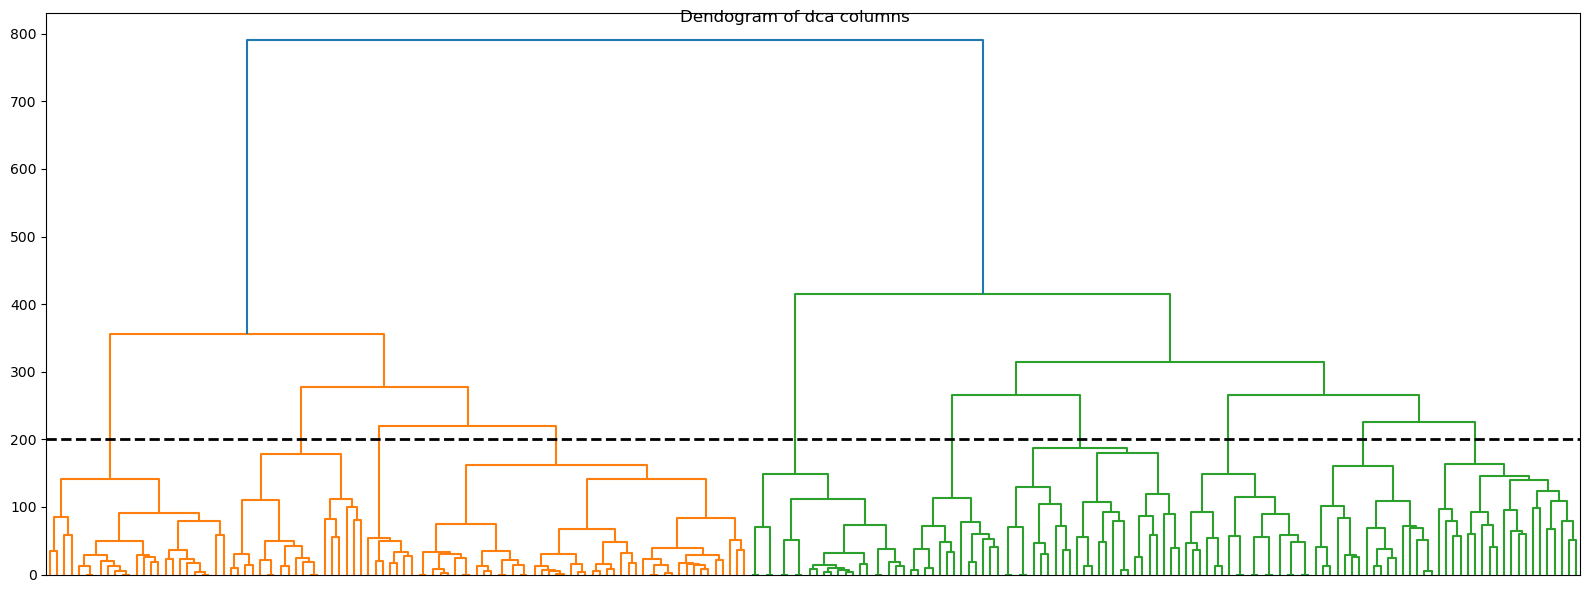

In [25]:
Z = linkage(X_scaled.T, method="ward", metric="euclidean")

fig = plt.figure(figsize=(16, 6))
dendrogram(
    Z,
    no_labels=True
)

plt.tight_layout()
fig.suptitle("Dendogram of dca columns")
plt.axhline(y=200, c='k', linestyle='--', linewidth=2) 
plt.show()

In [26]:
clusters_dca = fcluster(Z, t=13, criterion="maxclust")

cluster_map_dca = dict(zip(X_scaled.columns, clusters_dca))


cluster_df_dca = pd.DataFrame({
    "feature": X_scaled.columns,
    "cluster": clusters_dca
})
cluster_df_dca.head()

,feature,cluster
0,10y_dca_average_price,1
1,10y_dca_average_price_sats,6
2,10y_dca_cagr,9
3,10y_dca_days_in_profit,2
4,10y_dca_max_return,5


In [27]:
cluster_df_dca["cluster"].value_counts().sort_index()

cluster
1     25
2     13
3      6
4      7
5     46
6     22
7     13
8     10
9      8
10     7
11    18
12    17
13    20
Name: count, dtype: int64

In [ ]:
n = cluster_df_dca["cluster"].nunique()
clusters_dca_dict = {}
for i in range(1, n+1):
    clusters_dca_dict[i] = cluster_df_dca[cluster_df_dca["cluster"] == i]["feature"].tolist()


high_vif_dca = {}  # store results outside loop

for i in range(1, n+1):
    print(f"\nCluster {i}:")
    
    # 1. Filter to cluster's metrics and pivot to wide format
    x = (
        train.filter(pl.col("metric").is_in(clusters_dca_dict[i]))
        .pivot(index="day_utc", on="metric", values="value")
        .drop("day_utc")
        .to_pandas()
        .dropna()  # VIF can't handle nulls
    )
    
    if x.shape[1] < 2:
        print("  Skipping — need at least 2 features for VIF")
        continue

    # 2. Add constant and compute VIF
    X = add_constant(x)
    vif = pd.Series(
        [variance_inflation_factor(X.values, j) for j in range(X.shape[1])],
        index=X.columns
    )
    
    # 3. Drop the constant row and flag high VIF
    vif = vif.drop("const", errors="ignore")
    high_vif_dca[i] = vif[vif > 10].index.tolist()
    
    print(vif.sort_values(ascending=False).to_string())
    print(f"\n  High VIF cols (>10): {high_vif_dca[i]}")

In [ ]:
all_high_vif_dca = [col for cols in high_vif_dca.values() for col in cols]
len(all_high_vif_dca)

# Mining Pool Dendogram and VIF 

In [42]:
full_mining_family = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").str.contains("pool"))
    .collect()
)
len(full_mining_family)
full_mining_df = full_mining_family.to_pandas()

In [29]:
full_mining_df = full_mining_df.pivot(columns='metric',index='day_utc', values='value')
len(full_mining_df.columns)

1612

In [30]:
X = (
    full_mining_df
    .select_dtypes(include='number')
    .replace([np.inf, -np.inf], np.nan)
)
X = X.fillna(X.median())
X = X.loc[:, X.nunique() > 1]

X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X),
    index=X.index,
    columns=X.columns
)

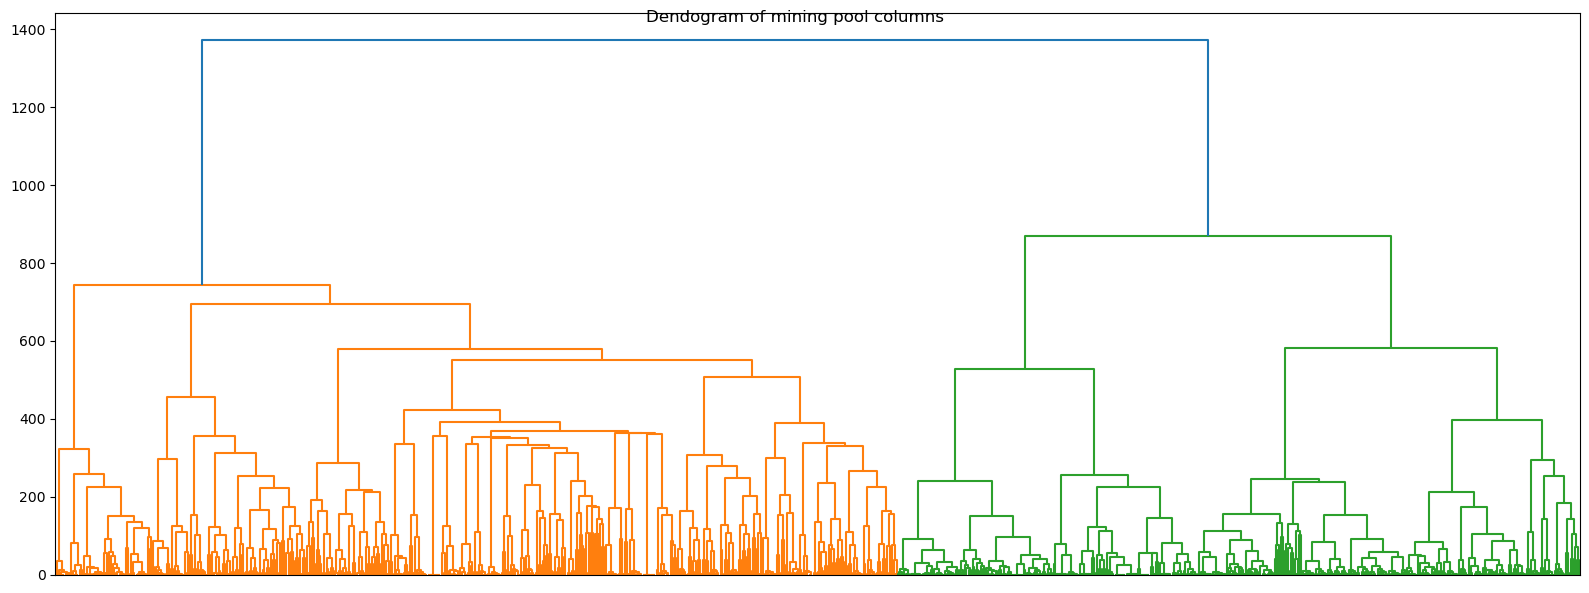

In [31]:
Z = linkage(X_scaled.T, method="ward", metric="euclidean")

fig = plt.figure(figsize=(16, 6))
dendrogram(
    Z,
    no_labels=True
)

plt.tight_layout()
fig.suptitle("Dendogram of mining pool columns")
plt.show()

In [32]:
clusters_mining_pool = fcluster(Z, t=300, criterion="distance")

cluster_map_mining_pool = dict(zip(X_scaled.columns, clusters_mining_pool))


cluster_df_mining_pool = pd.DataFrame({
    "feature": X_scaled.columns,
    "cluster": clusters_mining_pool
})
cluster_df_mining_pool.head()

,feature,cluster
0,aaopool_1m_blocks_mined,18
1,aaopool_1m_dominance,18
2,aaopool_1w_blocks_mined,18
3,aaopool_1w_dominance,18
4,aaopool_1y_blocks_mined,31


In [33]:
cluster_df_mining_pool["cluster"].value_counts().sort_index()

cluster
1      12
2      71
3      32
4      16
5      20
6      65
7      72
8      16
9      16
10     12
11     16
12     12
13     12
14     12
15     16
16     24
17     16
18     33
19     16
20     16
21     12
22     18
23     21
24     52
25     32
26     12
27     27
28     46
29    134
30    124
31    179
32    104
33     46
Name: count, dtype: int64

In [ ]:
n = cluster_df_mining_pool["cluster"].nunique()
clusters_mining_pool_dict = {}
for i in range(1, n+1):
    clusters_mining_pool_dict[i] = cluster_df_mining_pool[cluster_df_mining_pool["cluster"] == i]["feature"].tolist()


high_vif_mining_pool = {}  # store results outside loop

for i in range(1, n+1):
    print(f"\nCluster {i}:")
    
    # 1. Filter to cluster's metrics and pivot to wide format
    x = (
        train.filter(pl.col("metric").is_in(clusters_mining_pool_dict[i]))
        .pivot(index="day_utc", on="metric", values="value")
        .drop("day_utc")
        .to_pandas()
        .dropna()  # VIF can't handle nulls
    )
    
    if x.shape[1] < 2:
        print("  Skipping — need at least 2 features for VIF")
        continue

    # 2. Add constant and compute VIF
    X = add_constant(x)
    vif = pd.Series(
        [variance_inflation_factor(X.values, j) for j in range(X.shape[1])],
        index=X.columns
    )
    
    # 3. Drop the constant row and flag high VIF
    vif = vif.drop("const", errors="ignore")
    high_vif_mining_pool[i] = vif[vif > 10].index.tolist()
    
    print(vif.sort_values(ascending=False).to_string())
    print(f"\n  High VIF cols (>10): {high_vif_mining_pool[i]}")

In [ ]:
all_high_vif_mining_pool = [col for cols in high_vif_mining_pool.values() for col in cols]
len(all_high_vif_mining_pool)

In [ ]:
columns_to_drop_dict = {
    "columns_to_drop": all_high_vif_dca + all_high_vif_addrs + all_high_vif_cost_basis + all_high_vif_mining_pool
}
columns_to_drop = pd.DataFrame(columns_to_drop_dict)
columns_to_drop.to_csv("../columns_to_drop.csv", index=False)

### Checking the bitcoin crash 

In [34]:
some_cols = ["active_price","price_200d_sma","price_200d_sma_ratio_2y_sma","price_21d_ema","price_21d_ema_ratio_1y_0sd_usd","price_200d_ema","price_200d_ema_ratio","price_200d_ema_ratio_2y_0sd_usd"]

In [43]:
crash_df = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(
        (pl.col("day_utc") >= pl.date(2017, 1, 1)) & 
        ((pl.col("day_utc") <= pl.date(2018, 12, 31)))
    )
    .filter(pl.col("metric").is_in(["active_price","price_200d_sma","price_200d_sma_ratio_2y_sma","price_21d_ema","price_21d_ema_ratio_1y_0sd_usd","price_200d_ema","price_200d_ema_ratio_2y_0sd_usd", "price_21d_sma"]))
    .filter(pl.col("value").is_not_null())
    .collect()
)

In [36]:
fig_price = px.line(crash_df.to_pandas(), x='day_utc', y='value', color='metric', title='Price Metrics During Crash Period',facet_col="metric", facet_col_wrap=4)
fig_price.update_yaxes(matches=None)
fig_price.show()